# Synthetic Simulation of UAS Detection

## The Core IMM-EKF Engine

In [7]:
import numpy as np
from scipy.stats import multivariate_normal

class ThreatTracker_IMMEKF:
    def __init__(self, dt: float):
        self.dt = dt

        # 1. 3x3 Markov Transition Matrix (CV, CT_Left, CT_Right)
        self.Pi = np.array([
            [0.90, 0.05, 0.05],
            [0.05, 0.90, 0.05],
            [0.05, 0.05, 0.90]
        ])

        self.mu = np.array([0.8, 0.1, 0.1])
        self.omega_L = 0.35
        self.omega_R = -0.35
        self.q_cv = 0.3
        self.q_ct = 0.8
        self.R = np.diag([1.0, 0.005**2, 0.005**2])

        self.x_cv = np.zeros((6, 1))
        self.x_ctl = np.zeros((6, 1))
        self.x_ctr = np.zeros((6, 1))
        self.x_fused = np.zeros((6, 1))

        self.P_cv = np.eye(6) * 10.0
        self.P_ctl = np.eye(6) * 10.0
        self.P_ctr = np.eye(6) * 10.0
        self.P_fused = np.eye(6) * 10.0

    def _get_F_CV(self):
        F = np.eye(6)
        F[0, 3] = self.dt; F[1, 4] = self.dt; F[2, 5] = self.dt
        return F

    def _get_F_CT(self, omega):
        F = np.eye(6)
        wt = omega * self.dt
        F[0, 3] = np.sin(wt) / omega;       F[0, 4] = -(1 - np.cos(wt)) / omega
        F[1, 3] = (1 - np.cos(wt)) / omega; F[1, 4] = np.sin(wt) / omega
        F[2, 5] = self.dt
        F[3, 3] = np.cos(wt);               F[3, 4] = -np.sin(wt)
        F[4, 3] = np.sin(wt);               F[4, 4] = np.cos(wt)
        return F

    def _get_process_noise(self, q):
        G = np.zeros((6, 3))
        G[0, 0] = 0.5 * self.dt**2; G[3, 0] = self.dt
        G[1, 1] = 0.5 * self.dt**2; G[4, 1] = self.dt
        G[2, 2] = 0.5 * self.dt**2; G[5, 2] = self.dt
        return G @ (np.eye(3) * q) @ G.T

    def _measurement_function(self, x):
        px, py, pz = x[0,0], x[1,0], x[2,0]
        r = np.sqrt(px**2 + py**2 + pz**2)
        theta = np.arctan2(py, px)
        phi = np.arcsin(-pz / max(r, 1e-9))
        return np.array([[r], [theta], [phi]])

    def _measurement_jacobian(self, x):
        px, py, pz = x[0,0], x[1,0], x[2,0]
        r2 = max(px**2 + py**2 + pz**2, 1e-9)
        r = np.sqrt(r2)
        p2 = max(px**2 + py**2, 1e-9)
        p = np.sqrt(p2)
        H = np.zeros((3, 6))
        H[0, 0:3] = [px/r, py/r, pz/r]
        H[1, 0:3] = [-py/p2, px/p2, 0.0]
        H[2, 0:3] = [(px*pz)/(r2*p), (py*pz)/(r2*p), -p/r2]
        return H

    def step(self, z_measured):
        # 1. Mixing Step with numerical floor
        c = self.Pi.T @ self.mu
        mu_mix = (self.Pi * self.mu[:, None]) / (c + 1e-12)

        x_mix_cv  = mu_mix[0,0]*self.x_cv + mu_mix[1,0]*self.x_ctl + mu_mix[2,0]*self.x_ctr
        x_mix_ctl = mu_mix[0,1]*self.x_cv + mu_mix[1,1]*self.x_ctl + mu_mix[2,1]*self.x_ctr
        x_mix_ctr = mu_mix[0,2]*self.x_cv + mu_mix[1,2]*self.x_ctl + mu_mix[2,2]*self.x_ctr

        # 2. Prediction
        F_cv, F_ctl, F_ctr = self._get_F_CV(), self._get_F_CT(self.omega_L), self._get_F_CT(self.omega_R)
        x_pred_cv, x_pred_ctl, x_pred_ctr = F_cv @ x_mix_cv, F_ctl @ x_mix_ctl, F_ctr @ x_mix_ctr

        P_pred_cv = F_cv @ self.P_cv @ F_cv.T + self._get_process_noise(self.q_cv)
        P_pred_ctl = F_ctl @ self.P_ctl @ F_ctl.T + self._get_process_noise(self.q_ct)
        P_pred_ctr = F_ctr @ self.P_ctr @ F_ctr.T + self._get_process_noise(self.q_ct)

        # 3. Update / Likelihood Calculation
        models = [(x_pred_cv, P_pred_cv), (x_pred_ctl, P_pred_ctl), (x_pred_ctr, P_pred_ctr)]
        likelihoods = np.zeros(3)
        updated_states, updated_covs = [], []

        for i, (x_pred, P_pred) in enumerate(models):
            H = self._measurement_jacobian(x_pred)
            y_res = z_measured - self._measurement_function(x_pred)
            y_res[1,0] = (y_res[1,0] + np.pi) % (2 * np.pi) - np.pi
            y_res[2,0] = (y_res[2,0] + np.pi) % (2 * np.pi) - np.pi

            S = H @ P_pred @ H.T + self.R
            K = P_pred @ H.T @ np.linalg.inv(S)
            updated_states.append(x_pred + K @ y_res)
            updated_covs.append((np.eye(6) - K @ H) @ P_pred)

            try:
                # multivariate_normal.pdf can fail if S is singular or y_res contains NaNs
                l = multivariate_normal.pdf(y_res.flatten(), mean=np.zeros(3), cov=S, allow_singular=True)
                likelihoods[i] = max(l, 1e-12) # Safeguard against zero
            except:
                likelihoods[i] = 1e-12

        self.x_cv, self.x_ctl, self.x_ctr = updated_states
        self.P_cv, self.P_ctl, self.P_ctr = updated_covs

        # 4. Mode Probability Update with division-by-zero safeguard
        self.mu = c * likelihoods
        sum_mu = np.sum(self.mu)
        if sum_mu > 1e-20:
            self.mu /= sum_mu
        else:
            self.mu = np.array([1/3, 1/3, 1/3]) # Fallback to uniform if all models fail

        self.x_fused = self.mu[0]*self.x_cv + self.mu[1]*self.x_ctl + self.mu[2]*self.x_ctr
        return self.x_fused, self.mu

print("3-Model IMM-EKF Engine Initialized with numerical stability safeguards.")

3-Model IMM-EKF Engine Initialized with numerical stability safeguards.


## Monte Carlo Integration

In [6]:
import numpy as np
import time

def generate_evasive_trajectory(num_steps=400, dt=0.1, true_omega=0.35):
    """Generates a synthetic ground truth and noisy sensor measurement trajectory."""
    time_sim = np.arange(num_steps) * dt
    x_true, y_true, z_true = np.zeros(num_steps), np.zeros(num_steps), np.zeros(num_steps)
    z_measured = np.zeros((3, num_steps))

    # Initial conditions
    x_true[0], y_true[0], z_true[0] = 100.0, -50.0, -30.0
    vx, vy = 15.0, 0.0 # Cruising North at 15 m/s

    for i in range(1, num_steps):
        # Initiate evasive turn between t=15s and t=28s
        if 15.0 <= time_sim[i] <= 28.0:
            current_heading = true_omega * (time_sim[i] - 15.0)
            vx = 15.0 * np.cos(current_heading)
            vy = 15.0 * np.sin(current_heading)

        x_true[i] = x_true[i-1] + vx * dt
        y_true[i] = y_true[i-1] + vy * dt
        z_true[i] = z_true[i-1] # Constant altitude

        # Generate Noisy Measurements [Range, Azimuth, Elevation]
        r = np.sqrt(x_true[i]**2 + y_true[i]**2 + z_true[i]**2)
        theta = np.arctan2(y_true[i], x_true[i])
        phi = np.arcsin(-z_true[i] / max(r, 1e-9))

        # Inject Gaussian Noise matching the R matrix
        r_noisy = r + np.random.normal(0, 1.0)
        theta_noisy = theta + np.random.normal(0, 0.005)
        phi_noisy = phi + np.random.normal(0, 0.005)

        z_measured[:, i] = [r_noisy, theta_noisy, phi_noisy]

        # Inject 3-Second Visual Occlusion (t=22s to 25s)
        if 22.0 <= time_sim[i] <= 25.0:
            z_measured[:, i] = [np.nan, np.nan, np.nan]

    return time_sim, x_true, y_true, z_true, z_measured

# --- 100-RUN MONTE CARLO EXECUTION ---
num_simulations = 100
dt = 0.1

mc_pos_rmse = []
mc_vel_rmse = []
mc_occ_rmse = []
latencies = []

print(f"Initiating Monte Carlo Simulation ({num_simulations} runs)...")

for run in range(num_simulations):
    # Randomize the drone's true turn rate between 0.15 and 0.45 rad/s
    # Randomly assign a Left or Right bank
    true_omega = np.random.uniform(0.15, 0.45)
    if np.random.rand() > 0.5:
        true_omega *= -1.0

    time_sim, x_true, y_true, z_true, z_measured = generate_evasive_trajectory(num_steps=400, dt=dt, true_omega=true_omega)

    tracker = ThreatTracker_IMMEKF(dt=dt)
    tracker.x_cv[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
    tracker.x_ctl[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
    tracker.x_ctr[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
    tracker.x_cv[3:5, 0] = [15.0, 0.0]
    tracker.x_ctl[3:5, 0] = [15.0, 0.0]
    tracker.x_ctr[3:5, 0] = [15.0, 0.0]

    run_pos_errors = []
    run_vel_errors = []

    for i in range(1, len(time_sim)):
        z_k = z_measured[:, i:i+1]

        start_time = time.perf_counter()

        # Handle the 3-Second Optical Occlusion (NLOS)
        if np.isnan(z_k[0, 0]):
            pred_measurement = tracker._measurement_function(tracker.x_fused)
            x_fused, mu = tracker.step(pred_measurement)
        else:
            x_fused, mu = tracker.step(z_k)

        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000) # Convert to ms

        # 3D Position Error
        pos_err = np.sqrt((x_fused[0,0] - x_true[i])**2 +
                          (x_fused[1,0] - y_true[i])**2 +
                          (x_fused[2,0] - z_true[i])**2)
        run_pos_errors.append(pos_err)

        # 3D Velocity Error calculation matching ground truth dynamics
        current_heading = 0.0
        if time_sim[i] >= 15.0 and time_sim[i] <= 28.0:
            current_heading = true_omega * (time_sim[i] - 15.0)
        elif time_sim[i] > 28.0:
            current_heading = true_omega * 13.0

        vx_t = 15.0 * np.cos(current_heading)
        vy_t = 15.0 * np.sin(current_heading)

        vel_err = np.sqrt((x_fused[3,0] - vx_t)**2 +
                          (x_fused[4,0] - vy_t)**2 +
                          (x_fused[5,0] - 0.0)**2)
        run_vel_errors.append(vel_err)

    mc_pos_rmse.append(np.mean(run_pos_errors))
    mc_vel_rmse.append(np.mean(run_vel_errors))
    mc_occ_rmse.append(np.max(run_pos_errors[220:250])) # Max error during t=22s to 25s

# Calculate Final Statistical Aggregates
print("\n--- MONTE CARLO RESULTS (100 RUNS) ---")
print(f"3D Position RMSE:       {np.mean(mc_pos_rmse):.3f} m (± {np.std(mc_pos_rmse):.3f} m)")
print(f"Velocity RMSE:          {np.mean(mc_vel_rmse):.3f} m/s (± {np.std(mc_vel_rmse):.3f} m/s)")
print(f"Max Occlusion Error:    {np.mean(mc_occ_rmse):.3f} m (± {np.std(mc_occ_rmse):.3f} m)")
print(f"Avg Math Latency/Step:  {np.mean(latencies):.3f} ms")

Initiating Monte Carlo Simulation (100 runs)...

--- MONTE CARLO RESULTS (100 RUNS) ---
3D Position RMSE:       2.487 m (± 0.954 m)
Velocity RMSE:          2.319 m/s (± 0.787 m/s)
Max Occlusion Error:    27.308 m (± 13.861 m)
Avg Math Latency/Step:  1.374 ms


## Visualizations

<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_36246/3754108099.py:83: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_sim[1:], mu_history[:, 0], 'b-', linewidth=2, label='Model 1: Constant Velocity ($\mu_{CV}$)')
/tmp/ipykernel_36246/3754108099.py:84: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_sim[1:], mu_history[:, 1], 'r--', linewidth=2, label='Model 2: Left Bank ($\mu_{CT+}$)')
/tmp/ipykernel_36246/3754108099.py:85: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_sim[1:], mu_history[:, 2], 'g:', linewidth=2, label='Model 3: Right Bank ($\mu_{CT-}$)')
/tmp/ipykernel_36246/3

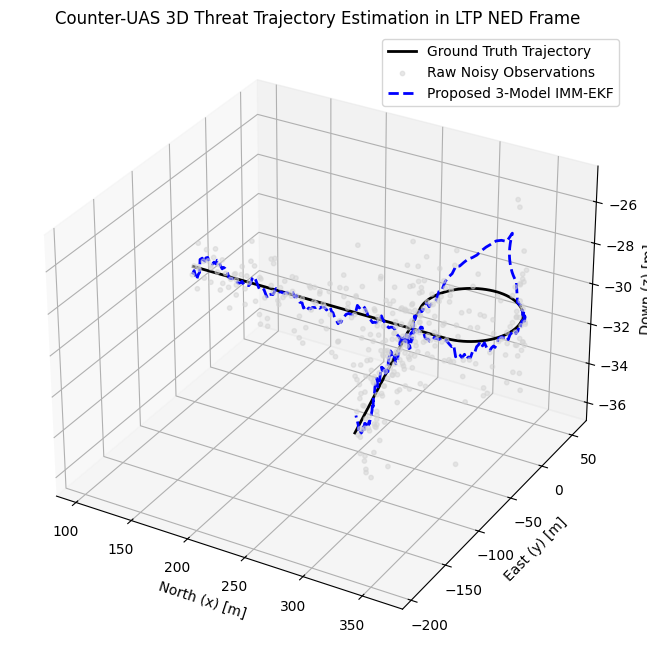

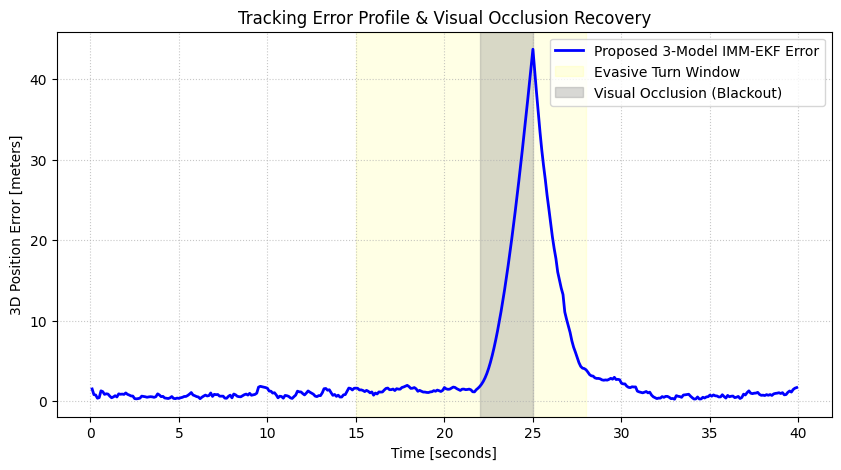

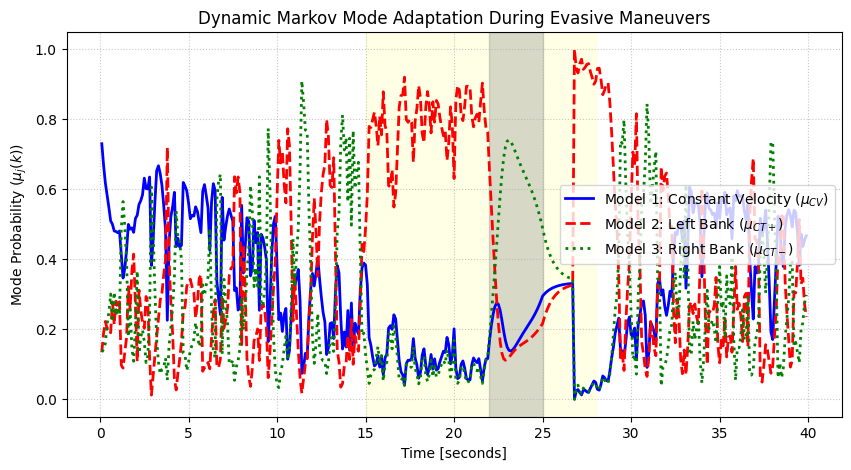

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches

# Extract a single representative run from the Monte Carlo simulation data
# (Assumes time_sim, x_true, y_true, z_true, z_measured, run_pos_errors, and the tracker's history are in memory from Cell 2)

# Re-run a single deterministic pass to capture the exact trajectory and mode probabilities for plotting
demo_tracker = ThreatTracker_IMMEKF(dt=0.1)
demo_tracker.x_cv[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
demo_tracker.x_ctl[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
demo_tracker.x_ctr[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
demo_tracker.x_cv[3:5, 0] = [15.0, 0.0]
demo_tracker.x_ctl[3:5, 0] = [15.0, 0.0]
demo_tracker.x_ctr[3:5, 0] = [15.0, 0.0]

est_x, est_y, est_z = [], [], []
mu_history = []

for i in range(1, len(time_sim)):
    z_k = z_measured[:, i:i+1]
    if np.isnan(z_k[0, 0]):
        pred_m = demo_tracker._measurement_function(demo_tracker.x_fused)
        x_fused, mu = demo_tracker.step(pred_m)
    else:
        x_fused, mu = demo_tracker.step(z_k)

    est_x.append(x_fused[0,0])
    est_y.append(x_fused[1,0])
    est_z.append(x_fused[2,0])
    mu_history.append(mu.copy())

mu_history = np.array(mu_history).squeeze()

# ---------------------------------------------------------
# FIGURE 1: 3D Trajectory Plot
# ---------------------------------------------------------
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

# Convert spherical noisy measurements back to Cartesian for plotting comparison
r_raw = z_measured[0, 1:]
theta_raw = z_measured[1, 1:]
phi_raw = z_measured[2, 1:]
x_raw = r_raw * np.cos(phi_raw) * np.cos(theta_raw)
y_raw = r_raw * np.cos(phi_raw) * np.sin(theta_raw)
z_raw = -r_raw * np.sin(phi_raw)

ax1.plot(x_true[1:], y_true[1:], z_true[1:], 'k-', linewidth=2, label='Ground Truth Trajectory')
ax1.scatter(x_raw, y_raw, z_raw, c='lightgray', s=10, alpha=0.5, label='Raw Noisy Observations')
ax1.plot(est_x, est_y, est_z, 'b--', linewidth=2, label='Proposed 3-Model IMM-EKF')

ax1.set_xlabel('North (x) [m]')
ax1.set_ylabel('East (y) [m]')
ax1.set_zlabel('Down (z) [m]') # Note: In NED, Down is negative altitude
ax1.set_title('Counter-UAS 3D Threat Trajectory Estimation in LTP NED Frame')
ax1.legend()
plt.savefig('trajectory_3d_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# FIGURE 2: Position Error & Visual Occlusion
# ---------------------------------------------------------
fig2 = plt.figure(figsize=(10, 5))
plt.plot(time_sim[1:], run_pos_errors, 'b-', linewidth=2, label='Proposed 3-Model IMM-EKF Error')

# Highlight the Evasive Turn and Occlusion Windows
plt.axvspan(15, 28, color='yellow', alpha=0.1, label='Evasive Turn Window')
plt.axvspan(22, 25, color='gray', alpha=0.3, label='Visual Occlusion (Blackout)')

plt.xlabel('Time [seconds]')
plt.ylabel('3D Position Error [meters]')
plt.title('Tracking Error Profile & Visual Occlusion Recovery')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.savefig('position_error_profile.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# FIGURE 3: Dynamic Markov Mode Probabilities
# ---------------------------------------------------------
fig3 = plt.figure(figsize=(10, 5))
plt.plot(time_sim[1:], mu_history[:, 0], 'b-', linewidth=2, label='Model 1: Constant Velocity ($\mu_{CV}$)')
plt.plot(time_sim[1:], mu_history[:, 1], 'r--', linewidth=2, label='Model 2: Left Bank ($\mu_{CT+}$)')
plt.plot(time_sim[1:], mu_history[:, 2], 'g:', linewidth=2, label='Model 3: Right Bank ($\mu_{CT-}$)')

# Highlight the Evasive Turn and Occlusion Windows
plt.axvspan(15, 28, color='yellow', alpha=0.1)
plt.axvspan(22, 25, color='gray', alpha=0.3)

plt.xlabel('Time [seconds]')
plt.ylabel('Mode Probability ($\mu_j(k)$)')
plt.title('Dynamic Markov Mode Adaptation During Evasive Maneuvers')
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='center right')
plt.savefig('mode_probabilities.png', dpi=300, bbox_inches='tight')
plt.show()